      Linear regression REGRESSION METRICS (Simple LR): sklearn vs From Scratch       
Metric          sklearn Train    Scratch Train     sklearn Test     Scratch Test
--------------------------------------------------------------------------------------
MSE                 0.000433        0.000433        0.000409        0.000409
RMSE                0.020804        0.020804        0.020213        0.020213
MAE                 0.014362        0.014362        0.014795        0.014795
R2                  0.000287        0.000287        0.000807        0.000807

Scratch parameters:
b0 (intercept) = 0.0010696742
b1 (slope)     = -0.0169433749

Sklearn parameters:
intercept_ = 0.0010696742
coef_      = -0.0169433749

=== DIRECTION ACCURACY ===
sklearn Train Direction Acc : 0.5273
scratch Train Direction Acc : 0.5273
sklearn Test Direction Acc  : 0.5247
scratch Test Direction Acc  : 0.5247

=== FINAL TEST RESULT ===
Best trial from stage 1 : simple_lr_baseline
Test loss               : 0.00040

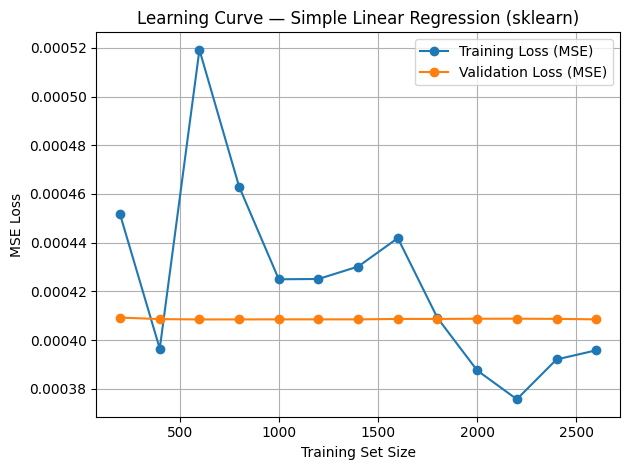

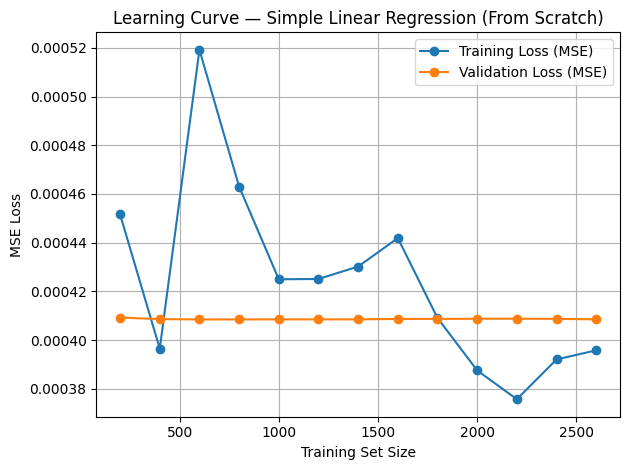

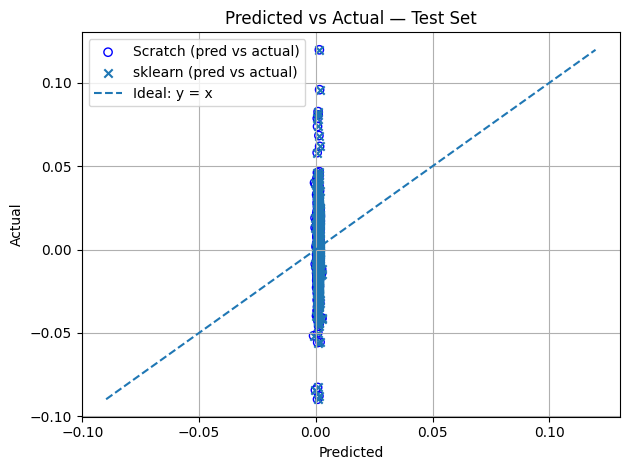

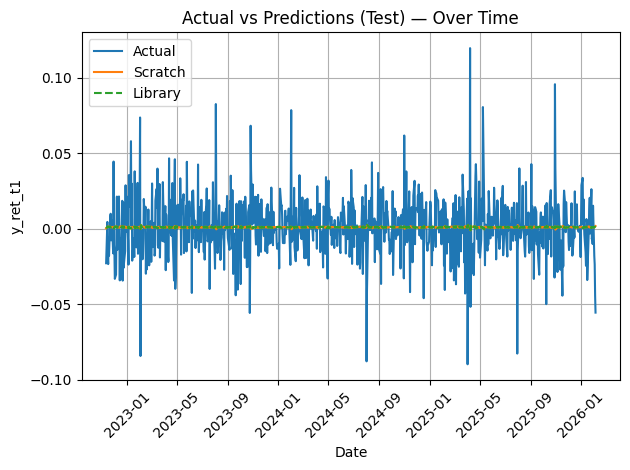

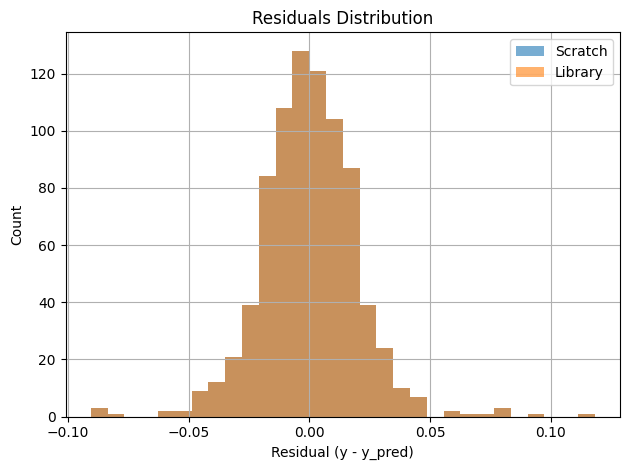

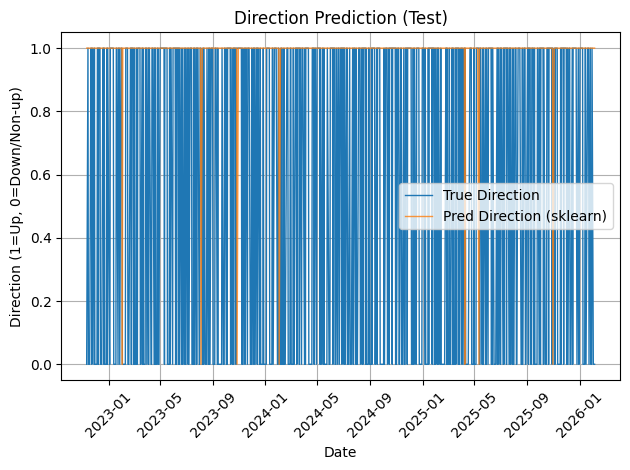

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
)

# ============================================================
# CONFIG
# ============================================================
CSV_PATH = "../SnP_daily_update_AMZN_features_with_target.csv"
DATE_COL = "Date"
X_COL = "ret_1"
Y_COL = "y_ret_t1"

TRAIN_RATIO = 0.8
MODEL_NAME = "Simple Linear Regression"
BEST_TRIAL_NAME = "simple_lr_baseline"
REPORT_TXT_PATH = "linear_regression_report.txt"

LC_TRAIN_SIZES = np.arange(200, 2601, 200)

# ============================================================
# Helpers
# ============================================================
def time_series_split(X, y, dates, train_ratio=0.8):
    n = len(X)
    tr_end = int(n * train_ratio)
    return (
        X[:tr_end], y[:tr_end], dates[:tr_end],
        X[tr_end:], y[tr_end:], dates[tr_end:]
    )

def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        "loss": mse,  # ใช้ MSE เป็น loss
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "pred_std": float(np.std(y_pred)),
        "true_std": float(np.std(y_true)),
    }

def direction_accuracy(y_true, y_pred, threshold=0.0):
    """
    Binary direction:
      1 = Up       (return > threshold)
      0 = Non-up   (return <= threshold)
    """
    y_true_dir = (y_true > threshold).astype(int)
    y_pred_dir = (y_pred > threshold).astype(int)
    return accuracy_score(y_true_dir, y_pred_dir)

def fit_simple_lr_scratch(x_train_1d, y_train):
    """
    Ordinary Least Squares closed-form for simple linear regression:
        y = b0 + b1*x
    """
    x = x_train_1d.astype(np.float64)
    y = y_train.astype(np.float64)

    x_mean = x.mean()
    y_mean = y.mean()

    sxx = np.sum((x - x_mean) ** 2)
    sxy = np.sum((x - x_mean) * (y - y_mean))

    if sxx == 0:
        b1 = 0.0
        b0 = y_mean
    else:
        b1 = sxy / sxx
        b0 = y_mean - b1 * x_mean

    return b0, b1

def predict_simple_lr(x_1d, b0, b1):
    return b0 + b1 * x_1d

def build_compare_table(sk_tr, sc_tr, sk_te, sc_te):
    lines = []
    lines.append("=" * 86)
    lines.append(f"{'Linear regression REGRESSION METRICS (Simple LR): sklearn vs From Scratch':^86}")
    lines.append("=" * 86)
    lines.append(f"{'Metric':<12} {'sklearn Train':>16} {'Scratch Train':>16} {'sklearn Test':>16} {'Scratch Test':>16}")
    lines.append("-" * 86)

    rows = [
        ("MSE",  "loss"),
        ("RMSE", "rmse"),
        ("MAE",  "mae"),
        ("R2",   "r2"),
    ]

    for label, key in rows:
        lines.append(
            f"{label:<12}"
            f"{sk_tr[key]:>16.6f}"
            f"{sc_tr[key]:>16.6f}"
            f"{sk_te[key]:>16.6f}"
            f"{sc_te[key]:>16.6f}"
        )

    lines.append("=" * 86)
    return "\n".join(lines)

def build_direction_block(sk_tr, sc_tr, sk_te, sc_te):
    lines = []
    lines.append("=== DIRECTION ACCURACY ===")
    lines.append(f"sklearn Train Direction Acc : {sk_tr['dir_acc']:.4f}")
    lines.append(f"scratch Train Direction Acc : {sc_tr['dir_acc']:.4f}")
    lines.append(f"sklearn Test Direction Acc  : {sk_te['dir_acc']:.4f}")
    lines.append(f"scratch Test Direction Acc  : {sc_te['dir_acc']:.4f}")
    return "\n".join(lines)

def build_params_block(b0, b1, sk_model):
    lines = []
    lines.append("Scratch parameters:")
    lines.append(f"b0 (intercept) = {b0:.10f}")
    lines.append(f"b1 (slope)     = {b1:.10f}")
    lines.append("")
    lines.append("Sklearn parameters:")
    lines.append(f"intercept_ = {sk_model.intercept_:.10f}")
    lines.append(f"coef_      = {sk_model.coef_[0]:.10f}")
    return "\n".join(lines)

def build_final_result_block(metrics, best_trial_name):
    lines = []
    lines.append("=== FINAL TEST RESULT ===")
    lines.append(f"Best trial from stage 1 : {best_trial_name}")
    lines.append(f"Test loss               : {metrics['loss']:.6f}")
    lines.append(f"Test RMSE               : {metrics['rmse']:.6f}")
    lines.append(f"Test MAE                : {metrics['mae']:.6f}")
    lines.append(f"Test R2                 : {metrics['r2']:.6f}")
    lines.append(f"Test Direction Acc      : {metrics['dir_acc']:.4f}")
    lines.append(f"Pred std                : {metrics['pred_std']:.6f}")
    lines.append(f"True std                : {metrics['true_std']:.6f}")
    return "\n".join(lines)

# ============================================================
# Load + prepare data
# ============================================================
df = pd.read_csv(CSV_PATH)

df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(DATE_COL).reset_index(drop=True)

data = df[[DATE_COL, X_COL, Y_COL]].dropna().copy()

dates_all = data[DATE_COL].to_numpy()
x_all = data[X_COL].to_numpy(dtype=np.float64)
y_all = data[Y_COL].to_numpy(dtype=np.float64)

# time-series split
x_train, y_train, dates_train, x_test, y_test, dates_test = time_series_split(
    x_all, y_all, dates_all, train_ratio=TRAIN_RATIO
)

# ============================================================
# 1) sklearn Simple Linear Regression
# ============================================================
sk_model = LinearRegression()
sk_model.fit(x_train.reshape(-1, 1), y_train)

sk_pred_train = sk_model.predict(x_train.reshape(-1, 1))
sk_pred_test = sk_model.predict(x_test.reshape(-1, 1))

# ============================================================
# 2) From-scratch Simple Linear Regression
# ============================================================
b0, b1 = fit_simple_lr_scratch(x_train, y_train)

sc_pred_train = predict_simple_lr(x_train, b0, b1)
sc_pred_test = predict_simple_lr(x_test, b0, b1)

# ============================================================
# Metrics
# ============================================================
sk_train_metrics = regression_metrics(y_train, sk_pred_train)
sk_test_metrics = regression_metrics(y_test, sk_pred_test)

sc_train_metrics = regression_metrics(y_train, sc_pred_train)
sc_test_metrics = regression_metrics(y_test, sc_pred_test)

sk_train_metrics["dir_acc"] = direction_accuracy(y_train, sk_pred_train)
sk_test_metrics["dir_acc"] = direction_accuracy(y_test, sk_pred_test)

sc_train_metrics["dir_acc"] = direction_accuracy(y_train, sc_pred_train)
sc_test_metrics["dir_acc"] = direction_accuracy(y_test, sc_pred_test)

# ============================================================
# Build full report text
# ============================================================
compare_table = build_compare_table(
    sk_train_metrics, sc_train_metrics, sk_test_metrics, sc_test_metrics
)

params_block = build_params_block(b0, b1, sk_model)

direction_block = build_direction_block(
    sk_train_metrics, sc_train_metrics, sk_test_metrics, sc_test_metrics
)

final_result_block = build_final_result_block(sk_test_metrics, BEST_TRIAL_NAME)

full_report = "\n\n".join([
    compare_table,
    params_block,
    direction_block,
    final_result_block,
])

# พิมพ์ออกมาทีเดียว ลดโอกาสโดน notebook ย่อกลางทาง
print(full_report)

# เซฟรายงานลงไฟล์ txt กัน output ใน notebook โดนย่อ
with open(REPORT_TXT_PATH, "w", encoding="utf-8") as f:
    f.write(full_report)

print(f"\nSaved full report to: {REPORT_TXT_PATH}")

# ============================================================
# Plot 1: Learning Curve (Train/Val MSE)
# ============================================================
train_mse_sk, val_mse_sk = [], []
train_mse_sc, val_mse_sc = [], []

x_val, y_val = x_test, y_test
train_sizes_used = []

for m in LC_TRAIN_SIZES:
    m = int(m)
    if m < 10 or m > len(x_train):
        continue

    train_sizes_used.append(m)

    x_sub = x_train[:m]
    y_sub = y_train[:m]

    # sklearn
    mdl = LinearRegression()
    mdl.fit(x_sub.reshape(-1, 1), y_sub)

    y_sub_pred_sk = mdl.predict(x_sub.reshape(-1, 1))
    y_val_pred_sk = mdl.predict(x_val.reshape(-1, 1))

    train_mse_sk.append(mean_squared_error(y_sub, y_sub_pred_sk))
    val_mse_sk.append(mean_squared_error(y_val, y_val_pred_sk))

    # scratch
    b0_sub, b1_sub = fit_simple_lr_scratch(x_sub, y_sub)
    y_sub_pred_sc = predict_simple_lr(x_sub, b0_sub, b1_sub)
    y_val_pred_sc = predict_simple_lr(x_val, b0_sub, b1_sub)

    train_mse_sc.append(mean_squared_error(y_sub, y_sub_pred_sc))
    val_mse_sc.append(mean_squared_error(y_val, y_val_pred_sc))

plt.figure()
plt.plot(train_sizes_used, train_mse_sk, marker="o", label="Training Loss (MSE)")
plt.plot(train_sizes_used, val_mse_sk, marker="o", label="Validation Loss (MSE)")
plt.title("Learning Curve — Simple Linear Regression (sklearn)")
plt.xlabel("Training Set Size")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(train_sizes_used, train_mse_sc, marker="o", label="Training Loss (MSE)")
plt.plot(train_sizes_used, val_mse_sc, marker="o", label="Validation Loss (MSE)")
plt.title("Learning Curve — Simple Linear Regression (From Scratch)")
plt.xlabel("Training Set Size")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2: Predicted vs Actual (test)
# ============================================================
plt.figure()
plt.scatter(
    sc_pred_test,
    y_test,
    facecolors="none",
    edgecolors="b",
    label="Scratch (pred vs actual)"
)
plt.scatter(
    sk_pred_test,
    y_test,
    marker="x",
    label="sklearn (pred vs actual)"
)

mn = min(sc_pred_test.min(), sk_pred_test.min(), y_test.min())
mx = max(sc_pred_test.max(), sk_pred_test.max(), y_test.max())
plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal: y = x")

plt.title("Predicted vs Actual — Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 3: Actual vs Predictions (test) over time
# ============================================================
plt.figure()
plt.plot(dates_test, y_test, label="Actual")
plt.plot(dates_test, sc_pred_test, label="Scratch")
plt.plot(dates_test, sk_pred_test, linestyle="--", label="Library")
plt.title("Actual vs Predictions (Test) — Over Time")
plt.xlabel("Date")
plt.ylabel(Y_COL)
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 4: Residual distribution (test)
# ============================================================
res_sc = y_test - sc_pred_test
res_sk = y_test - sk_pred_test

plt.figure()
plt.hist(res_sc, bins=30, alpha=0.6, label="Scratch")
plt.hist(res_sk, bins=30, alpha=0.6, label="Library")
plt.title("Residuals Distribution")
plt.xlabel("Residual (y - y_pred)")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 5: Direction comparison over time (test)
# ============================================================
true_dir = (y_test > 0).astype(int)
pred_dir = (sk_pred_test > 0).astype(int)

plt.figure()
plt.plot(dates_test, true_dir, label="True Direction", linewidth=1)
plt.plot(dates_test, pred_dir, label="Pred Direction (sklearn)", linewidth=1, alpha=0.8)
plt.title("Direction Prediction (Test)")
plt.xlabel("Date")
plt.ylabel("Direction (1=Up, 0=Down/Non-up)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()